# Analisis resultados modelo proactivo

## Grafico de estadigrafos de costo

In [150]:
import pandas as pd
from collections import defaultdict
import os
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


path_base = "resultados simulacion/ModeloBase_T4500_C4208/logs/0.csv"
path_proactivo = "resultados simulacion/ModeloProactivo_T4500_C4208/logs"

def calcular_costos_por_ciclo(df):
    ciclo_inicio = (df["TI"] // 12).astype(int)
    ciclo_final = (df["TF"] // 12).astype(int)

    costos = {
        "COSTO DER WL": defaultdict(float),
        "COSTO DER ED": defaultdict(float),
        "COSTO TRASLADO": defaultdict(float),
        "COSTO ESPERA WL": defaultdict(float),
        "COSTO ESPERA GA": defaultdict(float),
        "COSTO ESPERA TRATAMIENTO": defaultdict(float),
    }

    for col in ["COSTO DER WL", "COSTO DER ED", "COSTO TRASLADO"]:
        mask = df[col] > 0
        ciclos = ciclo_inicio[mask]
        valores = df.loc[mask, col]
        for c, v in zip(ciclos, valores):
            costos[col][c] += v

    espera_mask = df["COSTO ESPERA"] > 0
    unidades = df.loc[espera_mask, "UNIDAD"]
    ciclos_i = ciclo_inicio[espera_mask].values
    ciclos_f = ciclo_final[espera_mask].values
    costos_espera = df.loc[espera_mask, "COSTO ESPERA"].values

    for unidad, ci, cf, costo in zip(unidades, ciclos_i, ciclos_f, costos_espera):
        dur = cf - ci
        if dur <= 0:
            continue
        costo_ciclo = costo / dur

        if unidad == "WL":
            cat = "COSTO ESPERA WL"
        elif unidad == "GA":
            cat = "COSTO ESPERA GA"
        else:
            cat = "COSTO ESPERA TRATAMIENTO"

        for ciclo in range(ci, cf):
            costos[cat][ciclo] += costo_ciclo

    all_cycles = sorted(set(c for d in costos.values() for c in d))
    df_result = pd.DataFrame({"Ciclo": all_cycles})

    for col, dic in costos.items():
        df_result[col] = [dic.get(c, 0.0) for c in all_cycles]
    
    cols_costos = [col for col in costos.keys()]  # Lista de columnas de costo
    df_result["COSTO TOTAL"] = df_result[cols_costos].sum(axis=1)

    # Crear columna COSTO DER = COSTO DER WL + COSTO DER ED
    df_result["COSTO DERIVAR"] = df_result["COSTO DER WL"] + df_result["COSTO DER ED"]


    return df_result

def procesar_csvs(path):
    if os.path.isfile(path) and path.endswith(".csv"):
        df = pd.read_csv(path)
        return calcular_costos_por_ciclo(df)
    
    elif os.path.isdir(path):
        archivos = glob(os.path.join(path, "*.csv"))
        if not archivos:
            raise ValueError("No se encontraron archivos .csv en el directorio.")
        
        resultados = []
        for archivo in archivos:
            df = pd.read_csv(archivo)
            resultado = calcular_costos_por_ciclo(df)
            resultado["archivo"] = os.path.basename(archivo)
            resultados.append(resultado)

        df_concat = pd.concat(resultados)
        df_prom = df_concat.drop(columns="archivo").groupby("Ciclo").mean().reset_index()
        return df_prom
    
    else:
        raise ValueError("La ruta debe ser un archivo .csv o un directorio válido.")

def graficar_costos_promedio_movil(path, window_size=75, columnas_excluir=None, titulo="Costos por Ciclo"):
    
    df_resultado = procesar_csvs(path)
    # x = df_resultado["Ciclo"] * 12

    if columnas_excluir is None:
        columnas_excluir = ["Ciclo", "Ciclo agrupado", "COSTO DER WL", "COSTO DER ED"]
    
    df_suavizado = df_resultado.copy()
    for col in df_resultado.columns[1:]:  # omite "Ciclo"
        df_suavizado[col] = df_resultado[col].rolling(window=window_size, min_periods=1).mean()
    
    cols_a_graficar = [c for c in df_suavizado.columns if c not in columnas_excluir]

    # Definir grupos
    cols_espera = [col for col in cols_a_graficar if "ESPERA" in col]
    cols_otros = [col for col in cols_a_graficar if col not in cols_espera and col != "COSTO TOTAL"]

    # Paletas
    colores_espera = ['#3CB043', '#004225','#B4EC51'] 
    colores_otros = ["#F05C5C","#A30A0A"] 

    plt.figure(figsize=(14, 6))

    for col, color in zip(cols_espera, colores_espera):
        plt.plot(df_resultado["Ciclo"], df_suavizado[col], label=col, color=color, linewidth=1.2)

    for col, color in zip(cols_otros, colores_otros):
        plt.plot(df_resultado["Ciclo"], df_suavizado[col], label=col, color=color, linewidth=1.2)

    if "COSTO TOTAL" in df_suavizado.columns:
        plt.plot(df_resultado["Ciclo"], df_suavizado["COSTO TOTAL"], label="COSTO TOTAL", color="black", linewidth=1.5)
    
    for ciclo in [833, 3333]:
        plt.axvline(x=ciclo, color='black', linestyle='--', linewidth=2, alpha=1)
    
    if titulo == "Costos Simulación - Modelo Proactivo":
        plt.axvline(x=250, color='black', linestyle='--', linewidth=2, alpha=1)

    # Relabel x-axis ticks in hours (cycle * 12)
    # Define custom ticks: from 0 to 50000, every 10000
    # El rango en ciclos (eje x en ciclos)
    min_ciclo = 0
    max_ciclo = 50000 / 12  # ≈4166.67

    # Definir ticks en ciclos (cada 10000 horas => 10000/12 ciclos ≈ 833.33)
    ticks_ciclo = np.arange(min_ciclo, max_ciclo+1, 10000/12)

    # Ahora colocas esos ticks en eje x pero etiquetas con horas:
    plt.xticks(ticks=ticks_ciclo, labels=[f"{int(x*12)}" for x in ticks_ciclo])
    plt.xlim(min_ciclo, max_ciclo)

    plt.title(titulo, fontsize=14)
    plt.xlabel("Hora", fontsize=14)
    plt.ylabel("Costo", fontsize=14)
    plt.xlim(left=1)
    # plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(df_suavizado.columns)-1, fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    
    if titulo == "Costos Simulación - Modelo Proactivo":
        # Obtener ticks actuales (en ciclos)
        ticks_actuales = plt.xticks()[0]
        # Agregar el ciclo correspondiente a 3000 horas (250)
        nuevo_tick = 3000 / 12  # 250
        # Agregar y eliminar duplicados
        ticks_nuevos = np.unique(np.append(ticks_actuales, nuevo_tick))
        # Actualizar ticks y etiquetas (en horas)
        plt.xticks(ticks=ticks_nuevos, labels=[str(int(t * 12)) for t in ticks_nuevos])

    plt.show()

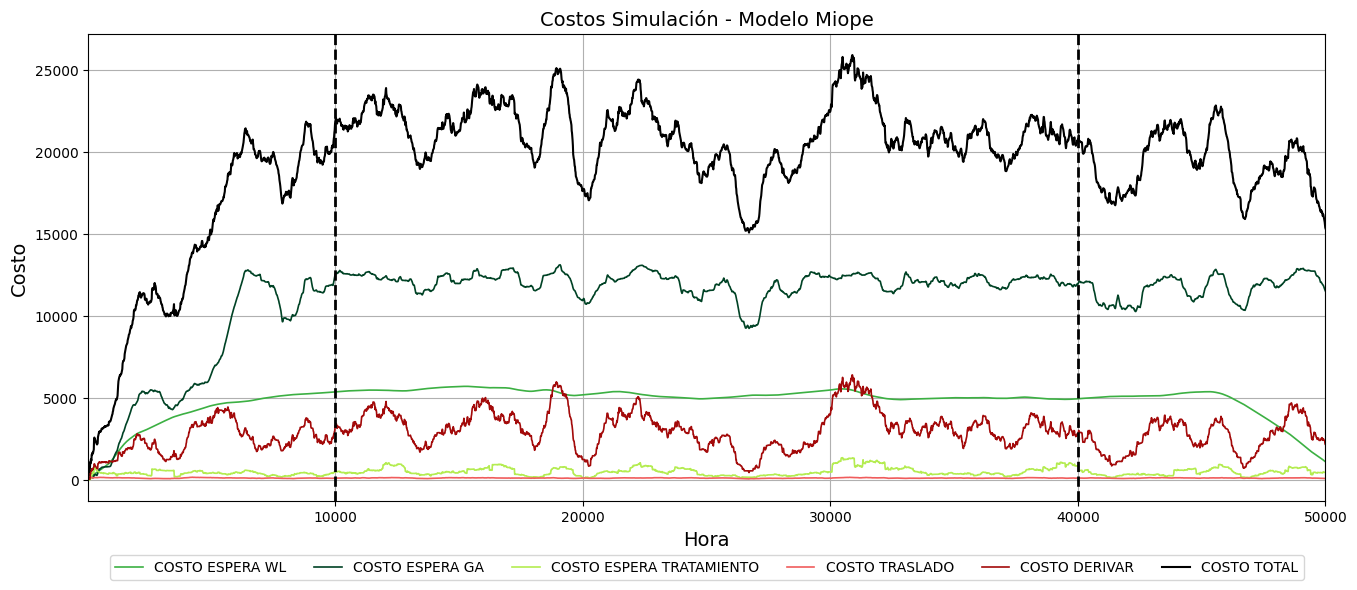

In [151]:
graficar_costos_promedio_movil(path_base, window_size=75, titulo="Costos Simulación - Modelo Miope")

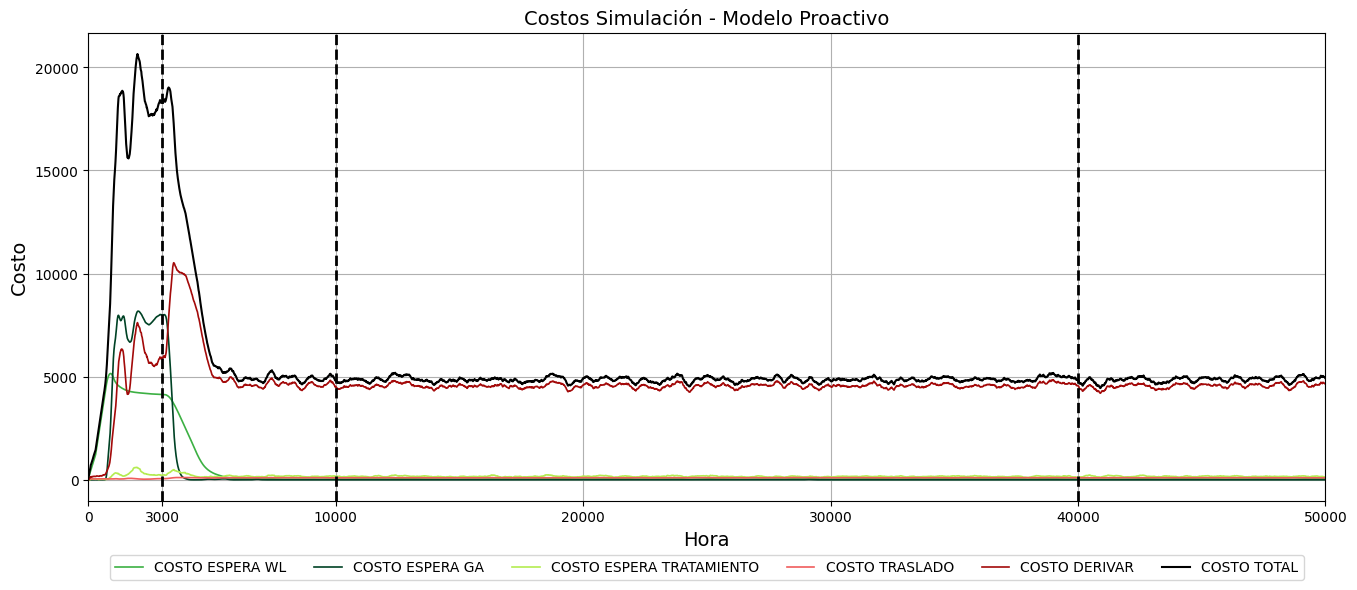

In [152]:
graficar_costos_promedio_movil(path_proactivo, window_size=25, titulo="Costos Simulación - Modelo Proactivo")

## LOS de fetter y indio

In [172]:
import os
import pandas as pd

def analizar_case_mix(df):
    # (Reusa la función que definimos antes)
    df["LOS"] = df["TF"] - df["TI"]
    # Filtrar rango de TI
    df = df[(df['TI'] >= 10000) & (df['TF'] <= 40000)]
    df_filtrado = df[~df['UNIDAD'].str.contains('WL', na=False)]
    ids_con_ps = df_filtrado[df_filtrado['UNIDAD'].str.contains('PS', na=False)]['ID'].unique()
    df_filtrado = df_filtrado[~df_filtrado['ID'].isin(ids_con_ps)]
    df_paciente = df_filtrado.groupby(['ID', 'MS_GRD'], as_index=False)['LOS'].sum()
    
    resumen = df_paciente.groupby('MS_GRD').agg(
        LOS_promedio=('LOS', 'mean'),
        n_pacientes=('ID', 'count')
    ).reset_index()
    resumen['LOS_promedio'] = resumen['LOS_promedio'].round(2)
    dict_A = resumen.set_index('MS_GRD')['LOS_promedio'].to_dict()
    total = resumen['n_pacientes'].sum()
    dict_P = (resumen.set_index('MS_GRD')['n_pacientes'] / total).round(4).to_dict()
    return resumen, dict_A, dict_P

def procesar_path(path):
    """
    Dado un path a un archivo CSV o a un directorio con CSVs,
    calcula A y P para cada CSV y luego promedia resultados.

    Retorna:
    - dict_A_promedio: promedio de LOS_promedio por MS_GRD
    - dict_P_promedio: promedio de proporción de pacientes por MS_GRD
    """

    def agregar_dicts_suma(dict_sum, dict_nueva):
        for k, v in dict_nueva.items():
            dict_sum[k] = dict_sum.get(k, 0) + v

    # Para acumular sumas de A y P
    suma_A = {}
    suma_P = {}
    n_archivos = 0

    if os.path.isfile(path) and path.endswith('.csv'):
        # Caso archivo único
        df = pd.read_csv(path)
        _, dict_A, dict_P = analizar_case_mix(df)
        return dict_A, dict_P

    elif os.path.isdir(path):
        # Caso directorio: buscar todos CSVs y acumular
        for filename in os.listdir(path):
            if filename.endswith('.csv'):
                filepath = os.path.join(path, filename)
                df = pd.read_csv(filepath)
                _, dict_A, dict_P = analizar_case_mix(df)
                agregar_dicts_suma(suma_A, dict_A)
                agregar_dicts_suma(suma_P, dict_P)
                n_archivos += 1
        if n_archivos == 0:
            raise ValueError("No se encontraron archivos CSV en el directorio.")
        # Calcular promedio
        dict_A_promedio = {k: round(v / n_archivos, 4) for k, v in suma_A.items()}
        dict_P_promedio = {k: round(v / n_archivos, 4) for k, v in suma_P.items()}
        return dict_A_promedio, dict_P_promedio

    else:
        raise ValueError("El path no es un archivo CSV válido ni un directorio.")

In [174]:
path_base_detallado = "resultados simulacion/ModeloBase_T4500_C4208/logs/0.csv"
path_base = "../2. data/0 TimeLog.csv"
path_proactivo = "resultados simulacion/ModeloProactivo_T4500_C4208/logs"

A_prom, P_prom = procesar_path(path_base_detallado)
a_prom, p_prom = procesar_path(path_proactivo)

print("Promedio A:", A_prom)
print("Promedio P:", P_prom)
print("Promedio a:", A_prom)
print("Promedio p:", P_prom)

Promedio A: {1: 364.53, 2: 439.32, 3: 182.69, 4: 318.97, 5: 245.69, 6: 158.2, 7: 409.83, 8: 388.23}
Promedio P: {1: 0.154, 2: 0.1431, 3: 0.1272, 4: 0.1265, 5: 0.1265, 6: 0.0885, 7: 0.1558, 8: 0.0783}
Promedio a: {1: 364.53, 2: 439.32, 3: 182.69, 4: 318.97, 5: 245.69, 6: 158.2, 7: 409.83, 8: 388.23}
Promedio p: {1: 0.154, 2: 0.1431, 3: 0.1272, 4: 0.1265, 5: 0.1265, 6: 0.0885, 7: 0.1558, 8: 0.0783}


In [182]:
# Construcción del DataFrame
df_comparacion = pd.DataFrame({
    'DRG': list(range(1, 9)),
    'A': [A_prom[i] for i in range(1, 9)],
    'P': [P_prom[i] for i in range(1, 9)],
    'a': [a_prom[i] for i in range(1, 9)],
    'p': [p_prom[i] for i in range(1, 9)],
})

# Calcular diferencias
df_comparacion['a - A'] = df_comparacion['a'] - df_comparacion['A']
df_comparacion['p - P'] = df_comparacion['p'] - df_comparacion['P']

df_comparacion["Δ LOS"] = ((df_comparacion["P"] + df_comparacion["p"]) * df_comparacion["a - A"])/2 
df_comparacion["Δ CM"] = ((df_comparacion["A"] + df_comparacion["a"]) * df_comparacion["p - P"])/2 

# Redondear todo a 4 decimales
df_comparacion = df_comparacion.round(2)
print(df_comparacion["Δ LOS"].sum())
print(df_comparacion["Δ CM"].sum())

delta_totales = {
    'DRG': '',
    'A': '',
    'P': '',
    'a': 'Total',
    'p': '',
    'a - A': '',
    'p - P': '',
    'Δ LOS': df_comparacion['Δ LOS'].sum(),
    'Δ CM': df_comparacion['Δ CM'].sum()
}

# Agregar al DataFrame original
df_comparacion = pd.concat([df_comparacion, pd.DataFrame([delta_totales])], ignore_index=True)

# Mostrar resultado redondeado
df_comparacion = df_comparacion.round(2)
df_comparacion

df_comparacion


-32.07
-11.710000000000003


,DRG,A,P,a,p,a - A,p - P,Δ LOS,Δ CM
0,1,364.53,0.15,355.25,0.14,-9.28,-0.01,-1.38,-3.71
1,2,439.32,0.14,428.05,0.14,-11.27,-0.01,-1.58,-2.60
2,3,182.69,0.13,169.12,0.15,-13.57,0.02,-1.88,4.05
3,4,318.97,0.13,307.29,0.12,-11.68,-0.0,-1.45,-1.35
4,5,245.69,0.13,199.51,0.13,-46.18,0.01,-6.03,1.83
5,6,158.2,0.09,136.41,0.12,-21.79,0.03,-2.22,3.96
6,7,409.83,0.16,338.08,0.12,-71.75,-0.03,-9.97,-12.60
7,8,388.23,0.08,289.31,0.07,-98.92,-0.0,-7.56,-1.29
8,,,,Total,,,,-32.07,-11.71
